<a href="https://colab.research.google.com/github/sruthi-kurra/fraud-detection-gnn/blob/main/03_gnn_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Cell 1 — Setup: upload data & build graph

In [1]:
# Upload & install
!pip install torch-geometric -q
from google.colab import files
import zipfile, pandas as pd, numpy as np
from sklearn.preprocessing import LabelEncoder

uploaded = files.upload()
with zipfile.ZipFile('ieee-fraud-detection.zip', 'r') as z:
    z.extractall('data/')

# Load & clean
train_txn = pd.read_csv('data/train_transaction.csv')
train_id  = pd.read_csv('data/train_identity.csv')
df = train_txn.merge(train_id, on='TransactionID', how='left')

core_cols = ['TransactionID', 'TransactionDT', 'TransactionAmt',
             'card1', 'card4', 'ProductCD', 'P_emaildomain',
             'R_emaildomain', 'addr1', 'isFraud']
df = df[core_cols].copy()
df['addr1']          = df['addr1'].fillna(-1)
df['P_emaildomain']  = df['P_emaildomain'].fillna('unknown')
df['R_emaildomain']  = df['R_emaildomain'].fillna('unknown')
df['card4']          = df['card4'].fillna('unknown')
df['TransactionAmt'] = df['TransactionAmt'].fillna(df['TransactionAmt'].median())

# Build graph
le = LabelEncoder()
df['card4_enc']          = le.fit_transform(df['card4'])
df['ProductCD_enc']      = le.fit_transform(df['ProductCD'])
df['P_emaildomain_enc']  = le.fit_transform(df['P_emaildomain'])

node_features = df.groupby('card1').agg(
    total_transactions = ('TransactionID', 'count'),
    total_amount       = ('TransactionAmt', 'sum'),
    avg_amount         = ('TransactionAmt', 'mean'),
    max_amount         = ('TransactionAmt', 'max'),
    unique_products    = ('ProductCD_enc', 'nunique'),
    unique_emails      = ('P_emaildomain_enc', 'nunique'),
    fraud_label        = ('isFraud', 'max')
).reset_index()

card1_to_idx = {card1: idx for idx, card1 in enumerate(node_features['card1'])}
edges = df.groupby('P_emaildomain')['card1'].apply(list).reset_index()
src_nodes, dst_nodes = [], []
for _, row in edges.iterrows():
    accounts = row['card1']
    if len(accounts) > 1:
        for i in range(len(accounts)):
            for j in range(i+1, min(i+5, len(accounts))):
                src = card1_to_idx.get(accounts[i])
                dst = card1_to_idx.get(accounts[j])
                if src is not None and dst is not None:
                    src_nodes.append(src)
                    dst_nodes.append(dst)

import torch
from torch_geometric.data import Data

feature_cols = ['total_transactions', 'total_amount', 'avg_amount',
                'max_amount', 'unique_products', 'unique_emails']
x          = torch.tensor(node_features[feature_cols].values, dtype=torch.float)
y          = torch.tensor(node_features['fraud_label'].values, dtype=torch.long)
edge_index = torch.tensor([src_nodes, dst_nodes], dtype=torch.long)
data       = Data(x=x, edge_index=edge_index, y=y)

print(data)
print(f"Fraud nodes: {data.y.sum().item()} / {data.y.shape[0]}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 25.9 MB/s eta 0:00:00


Saving ieee-fraud-detection.zip to ieee-fraud-detection.zip
Data(x=[13553, 6], edge_index=[2, 2361560], y=[13553])
Fraud nodes: 1740 / 13553


## Cell 2 — Define the GNN model

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv

class FraudGNN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(FraudGNN, self).__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, hidden_channels)
        self.conv3 = SAGEConv(hidden_channels, out_channels)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.conv3(x, edge_index)
        return x

# Initialize model
model = FraudGNN(
    in_channels=data.x.shape[1],   # 6 features
    hidden_channels=64,
    out_channels=2                  # fraud or legit
)

print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters())}")

FraudGNN(
  (conv1): SAGEConv(6, 64, aggr=mean)
  (conv2): SAGEConv(64, 64, aggr=mean)
  (conv3): SAGEConv(64, 2, aggr=mean)
  (dropout): Dropout(p=0.3, inplace=False)
)

Total parameters: 9346


## Cell 3 — Train the GNN

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Normalize node features
scaler = StandardScaler()
x_scaled = scaler.fit_transform(data.x.numpy())
data.x = torch.tensor(x_scaled, dtype=torch.float)
print("Features normalized!")

# Train/test split
idx = torch.arange(data.num_nodes)
train_idx, test_idx = train_test_split(
    idx.numpy(), test_size=0.2, random_state=42,
    stratify=data.y.numpy()
)
train_idx = torch.tensor(train_idx)
test_idx  = torch.tensor(test_idx)

# Reinitialize model fresh
model = FraudGNN(in_channels=data.x.shape[1], hidden_channels=64, out_channels=2)

# Class weights
fraud_weight = (data.y == 0).sum().float() / (data.y == 1).sum().float()
weights   = torch.tensor([1.0, fraud_weight * 0.7])
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

def train():
    model.train()
    optimizer.zero_grad()
    out  = model(data.x, data.edge_index)
    loss = criterion(out[train_idx], data.y[train_idx])
    loss.backward()
    optimizer.step()
    return loss.item()

def test(idx):
    model.eval()
    with torch.no_grad():
        out  = model(data.x, data.edge_index)
        pred = out.argmax(dim=1)
        correct = (pred[idx] == data.y[idx]).sum().item()
        acc = correct / len(idx)
    return acc

print("Training GNN...")
for epoch in range(1, 301):
    loss = train()
    if epoch % 10 == 0:
        train_acc = test(train_idx)
        test_acc  = test(test_idx)
        print(f"Epoch {epoch:3d} | Loss: {loss:.4f} | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")

print("\nTraining complete!")

Features normalized!
Training GNN...
Epoch  10 | Loss: 0.8439 | Train Acc: 0.8031 | Test Acc: 0.7864
Epoch  20 | Loss: 0.7141 | Train Acc: 0.8408 | Test Acc: 0.8395
Epoch  30 | Loss: 0.6821 | Train Acc: 0.8965 | Test Acc: 0.8938
Epoch  40 | Loss: 0.6351 | Train Acc: 0.8968 | Test Acc: 0.8934
Epoch  50 | Loss: 0.6203 | Train Acc: 0.8948 | Test Acc: 0.8897
Epoch  60 | Loss: 0.6018 | Train Acc: 0.8799 | Test Acc: 0.8823
Epoch  70 | Loss: 0.5713 | Train Acc: 0.8447 | Test Acc: 0.8525
Epoch  80 | Loss: 0.5614 | Train Acc: 0.8568 | Test Acc: 0.8624
Epoch  90 | Loss: 0.5398 | Train Acc: 0.8616 | Test Acc: 0.8654
Epoch 100 | Loss: 0.5371 | Train Acc: 0.8688 | Test Acc: 0.8713
Epoch 110 | Loss: 0.5297 | Train Acc: 0.8542 | Test Acc: 0.8587
Epoch 120 | Loss: 0.5238 | Train Acc: 0.8723 | Test Acc: 0.8753
Epoch 130 | Loss: 0.5280 | Train Acc: 0.8669 | Test Acc: 0.8687
Epoch 140 | Loss: 0.5234 | Train Acc: 0.8711 | Test Acc: 0.8731
Epoch 150 | Loss: 0.5170 | Train Acc: 0.8738 | Test Acc: 0.8790
Epo

## Cell 4 — Evaluate results

=== GNN Results ===
              precision    recall  f1-score   support

       Legit       0.94      0.89      0.91      2363
       Fraud       0.44      0.58      0.50       348

    accuracy                           0.85      2711
   macro avg       0.69      0.74      0.71      2711
weighted avg       0.87      0.85      0.86      2711

AUC-ROC: 0.8389


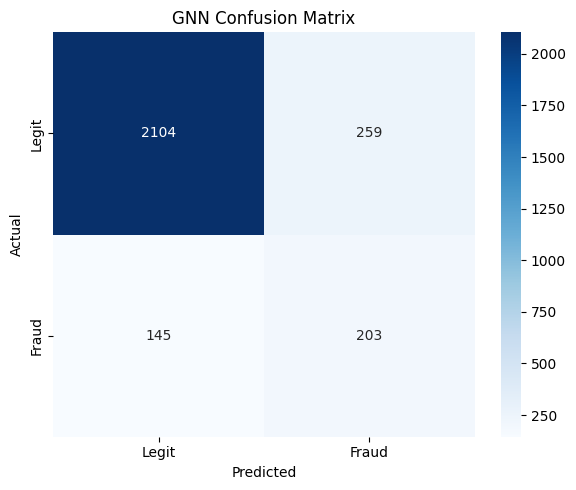

In [10]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

model.eval()
with torch.no_grad():
    out  = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)
    prob = torch.softmax(out, dim=1)[:, 1]

# Get test predictions
y_true = data.y[test_idx].numpy()
y_pred = pred[test_idx].numpy()
y_prob = prob[test_idx].numpy()

# Classification report
print("=== GNN Results ===")
print(classification_report(y_true, y_pred, target_names=['Legit', 'Fraud']))
print(f"AUC-ROC: {roc_auc_score(y_true, y_prob):.4f}")

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legit', 'Fraud'],
            yticklabels=['Legit', 'Fraud'])
plt.title('GNN Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('gnn_confusion_matrix.png', dpi=120)
plt.show()